In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from pyecharts.charts import Map
from pyecharts import options as opts

In [2]:
df = pd.read_csv('./tmall_order_report.csv')
df.head()

,订单编号,总金额,买家实际支付金额,收货地址,订单创建时间,订单付款时间,退款金额
0,1,178.8,0.0,上海,2020-02-21 00:00:00,NaN,0.0
1,2,21.0,21.0,内蒙古自治区,2020-02-20 23:59:54,2020-02-21 00:00:02,0.0
2,3,37.0,0.0,安徽省,2020-02-20 23:59:35,NaN,0.0
3,4,157.0,157.0,湖南省,2020-02-20 23:58:34,2020-02-20 23:58:44,0.0
4,5,64.8,0.0,江苏省,2020-02-20 23:57:04,2020-02-20 23:57:11,64.8


In [3]:
# 总订单量
total_orders = len(df)
total_orders

28010

In [4]:
# 总成交额（买家实际支付金额总和）
total_revenue = df['买家实际支付金额'].sum()
total_revenue

np.float64(1902487.15)

In [5]:
# 平均订单金额
average_order_value = round(df['买家实际支付金额'].mean(), 2)
average_order_value

np.float64(67.92)

In [6]:
# 退款总额
total_refund = round(df['退款金额'].sum(), 2)
total_refund

np.float64(572335.92)

In [7]:
# 退款订单数
refund_order_count = (df['退款金额'] > 0).sum()
refund_order_count

np.int64(5646)

In [8]:
# 退款率
refund_rate = round(refund_order_count/total_orders, 4)
refund_rate

np.float64(0.2016)

In [9]:
# 打印结果
print(f"总订单量：{total_orders}")
print(f"总成交额：{total_revenue} 元")
print(f"平均订单金额：{average_order_value} 元")
print(f"退款总额：{total_refund} 元")
print(f"退款订单数：{refund_order_count}")
print(f"退款率：{refund_rate*100}%")

总订单量：28010
总成交额：1902487.15 元
平均订单金额：67.92 元
退款总额：572335.92 元
退款订单数：5646
退款率：20.16%


In [10]:
# 设置默认字体为黑体，解决中文乱码
matplotlib.rcParams['font.family'] = 'SimHei'

In [11]:
# 清除列名中的空格
df.columns = df.columns.str.strip()
# 订单创建时间转为 datetime 类型
df['订单创建时间'] = pd.to_datetime(df['订单创建时间'])
df['订单付款时间'] = pd.to_datetime(df['订单付款时间'])

# 提取日期部分
df['创建日期'] = df['订单创建时间'].dt.date
df['付款日期'] = df['订单付款时间'].dt.date

# 按创建日期统计下单量
daily_orders = df.groupby('创建日期').size()

# 按付款日期统计付款量
daily_payments = df[df['订单付款时间'].notna()].groupby('付款日期').size()

In [12]:
# 提取小时
df['创建小时'] = df['订单创建时间'].dt.hour
df['付款小时'] = df['订单付款时间'].dt.hour

# 按小时统计下单量
hourly_orders = df.groupby('创建小时').size()

# 按小时统计付款量
hourly_payments = df[df['订单付款时间'].notna()].groupby('付款小时').size()

In [13]:
df['付款延迟（分钟）'] = (df['订单付款时间'] - df['订单创建时间']).dt.total_seconds() / 60

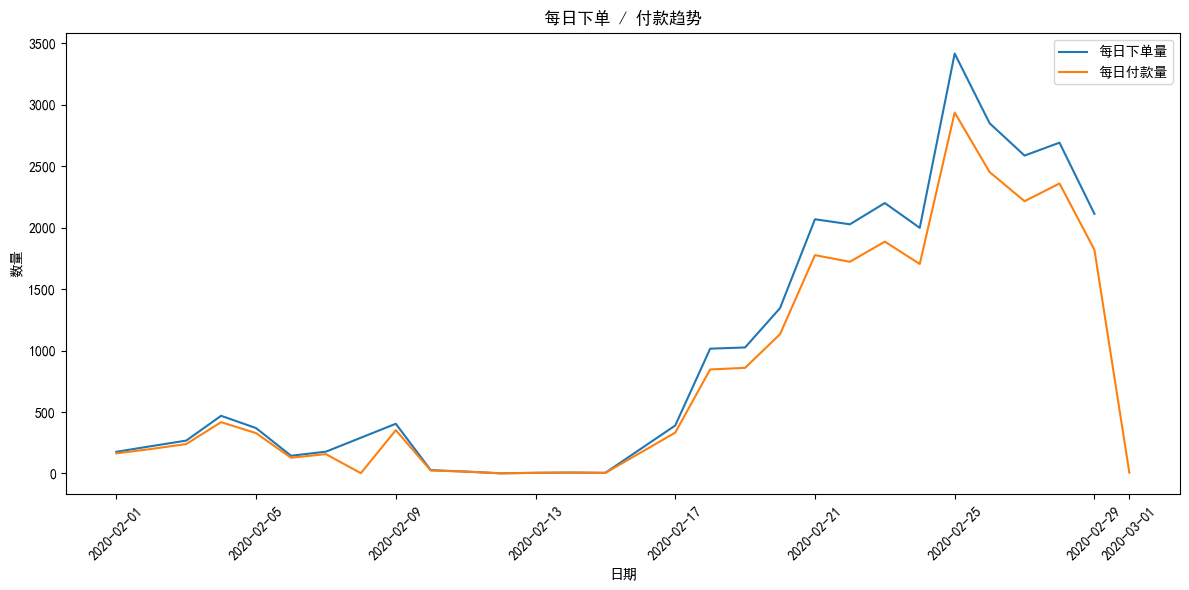

In [14]:
# 每日下单 / 付款趋势
plt.figure(figsize=(12, 6))
daily_orders.plot(label='每日下单量')
daily_payments.plot(label='每日付款量')
plt.title('每日下单 / 付款趋势')
plt.xlabel('日期')
plt.ylabel('数量')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

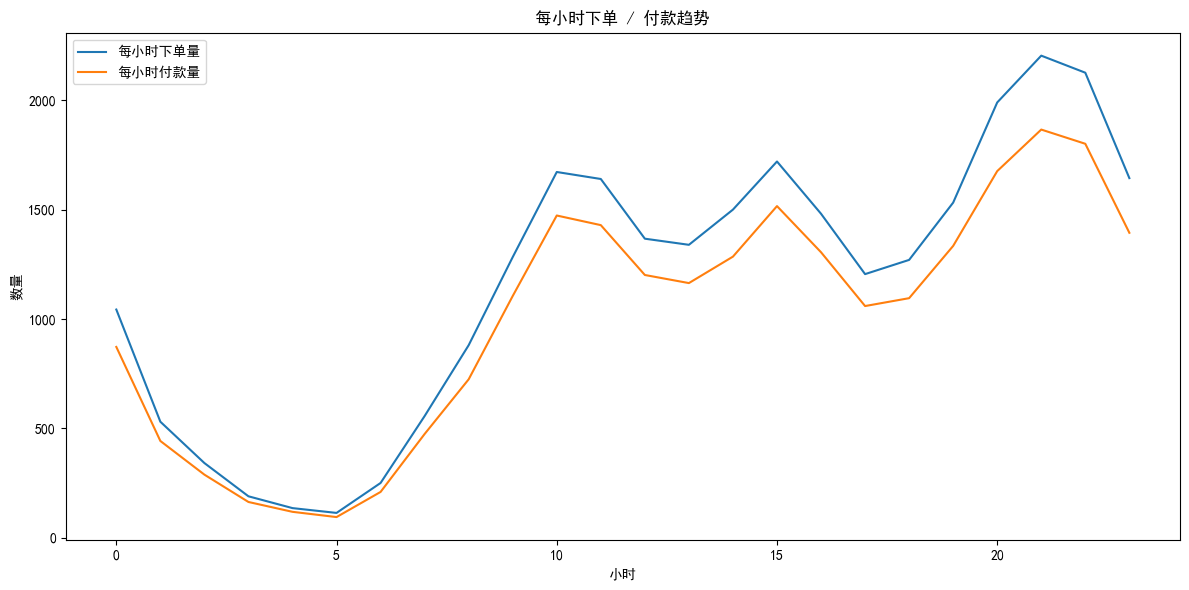

In [15]:
# 每小时下单 / 付款趋势
plt.figure(figsize=(12, 6))
hourly_orders.plot(label='每小时下单量')
hourly_payments.plot(label='每小时付款量')
plt.title('每小时下单 / 付款趋势')
plt.xlabel('小时')
plt.ylabel('数量')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

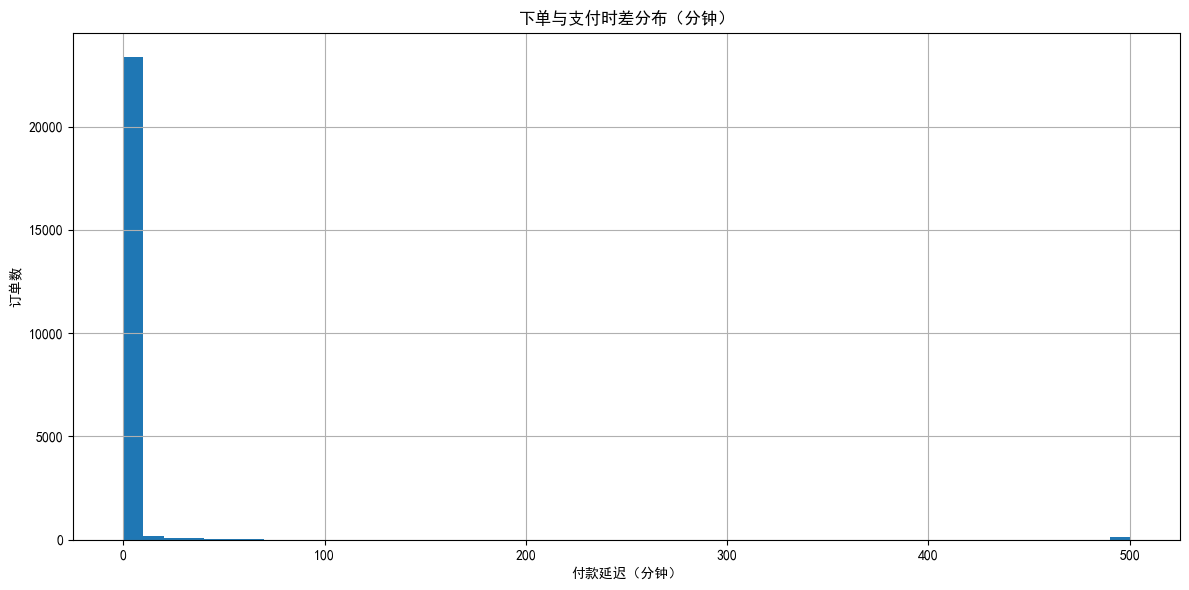

In [16]:
# 下单与支付时差分布
plt.figure(figsize=(12, 6))
df['付款延迟（分钟）'].dropna().clip(0, 500).hist(bins=50)
plt.title('下单与支付时差分布（分钟）')
plt.xlabel('付款延迟（分钟）')
plt.ylabel('订单数')
plt.tight_layout()
plt.show()

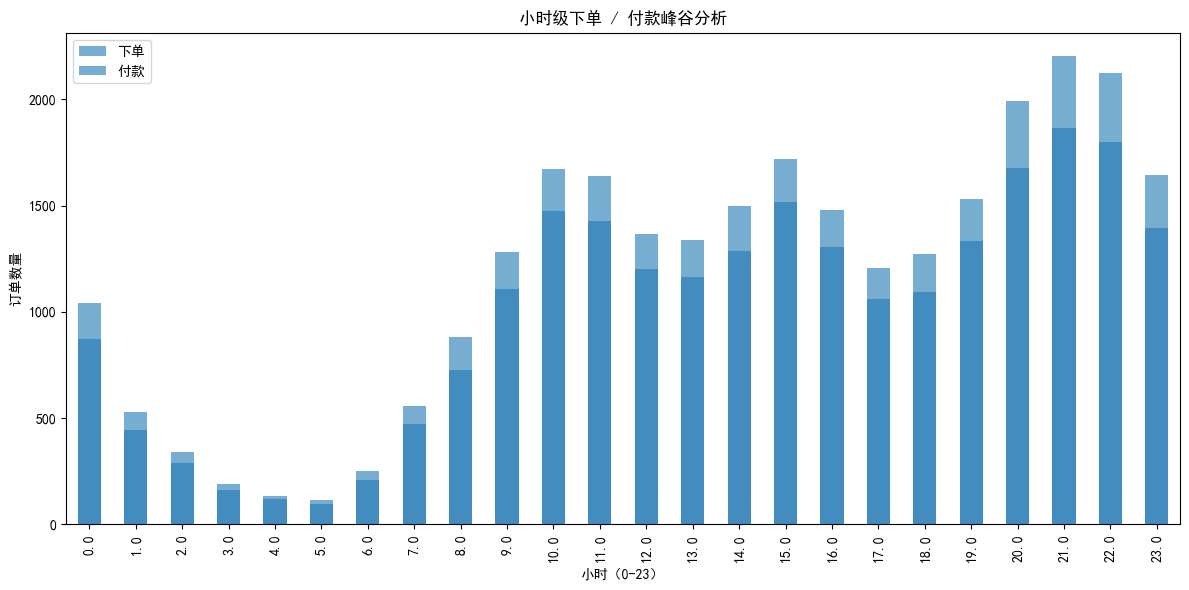

In [17]:
# 小时级峰谷分析
plt.figure(figsize=(12, 6))
hourly_orders.plot(kind='bar', alpha=0.6, label='下单')
hourly_payments.plot(kind='bar', alpha=0.6, label='付款')
plt.title('小时级下单 / 付款峰谷分析')
plt.xlabel('小时（0-23）')
plt.ylabel('订单数量')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# 全局漏斗
# 下单转支付转化率（空值为 False ）
paid_count = df['订单付款时间'].notna().sum()
pay_rate = paid_count / total_orders
pay_rate

np.float64(0.8599428775437343)

In [19]:
# 支付后退款率
refund_rate

np.float64(0.2016)

In [20]:
# 输出
print(f"总下单数：{total_orders}")
print(f"支付订单数：{paid_count}")
print(f"退款订单数：{refund_order_count}")
print(f"下单→支付转化率：{pay_rate:.2%}")
print(f"支付→退款率：{refund_rate:.2%}")

总下单数：28010
支付订单数：24087
退款订单数：5646
下单→支付转化率：85.99%
支付→退款率：20.16%


In [21]:
# 按省份统计订单数
province_order_count = df['收货地址'].value_counts().reset_index()
province_order_count.columns = ['省份', '订单数']

In [22]:
# 转换为 pyecharts 所需格式
data = list(zip(province_order_count['省份'], province_order_count['订单数']))

In [23]:
# 创建地图对象
map_chart = (
    Map(init_opts=opts.InitOpts(width="100%", height="800px"))
    .add("订单数", data, "china")
    .set_global_opts(
        title_opts=opts.TitleOpts(title="各省订单数分布图"),
        visualmap_opts=opts.VisualMapOpts(max_=province_order_count['订单数'].max())
    )
)

In [24]:
# 渲染成 HTML 可视化文件
map_chart.render("订单分布地图.html")

'C:\\Users\\31923\\Desktop\\Project\\12 天猫用户行为分析\\订单分布地图.html'